In [1]:
# Imports
import os
import random
import torch
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Reproductibiity
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
print("Seed set for reproducibility.")

Seed set for reproducibility.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
os.environ["KAGGLE_API_TOKEN"] = "KGAT_be0e6442f3cfdebedc0159d19b1ef38d"

In [5]:
!pip install kaggle

In [6]:
import os
os.environ["KAGGLE_API_TOKEN"] = "KGAT_3590e3cb03b6f7dd8ed313cbd31d5e4a"

In [7]:
!pip install kaggle

In [8]:
!kaggle competitions list

ref                                                                              deadline             category         reward  teamCount  userHasEntered  
-------------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge      2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                               2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                       2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection             2023-06-14 23:59:00  Featured  1,000,000 Usd       1249           False  
https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3          

In [10]:
from google.colab import files
files.upload()

KeyboardInterrupt: 

import os

os.makedirs('/root/.config/kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.config/kaggle/kaggle.json')
os.chmod('/root/.config/kaggle/kaggle.json', 600)

In [11]:
!pip install kaggle

In [12]:
!kaggle competitions list

ref                                                                              deadline             category         reward  teamCount  userHasEntered  
-------------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge      2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                               2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                       2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection             2023-06-14 23:59:00  Featured  1,000,000 Usd       1249           False  
https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3          

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!kaggle competitions download -c paddy-disease-classification -p /content/drive/MyDrive/paddy_project

You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


In [5]:
!unzip -q /content/drive/MyDrive/paddy_project/paddy-disease-classification.zip -d /content/drive/MyDrive/paddy_project/

replace /content/drive/MyDrive/paddy_project/sample_submission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [9]:
!ls /content/drive/MyDrive

'3. DC machines notes_copy.pdf'
 Classroom
'Colab Notebooks'
'Document from Charan Deep'
 paddy_project
 PHYSICS.pdf.gdrive
'Presentation (1).pdf'
'Presentation (1).pptx'
'Query Resolution Template 2025 - Round 1 CodeVita Season 13 (2).xlsx'
 Untitled0.ipynb
 Untitled1.ipynb
'Untitled presentation.gslides'
'Use a split screen. On the left, a "Before" image ....gdoc'


In [10]:
!ls /content/drive/MyDrive/paddy_project

best_resnet18.pth  models			     sample_submission.csv
class_to_idx.pkl   paddy-disease-classification.zip  test_images
fold_indices.pkl   predictions			     train.csv
logs		   resnet18_fold0_epoch1.pth	     train_images


In [11]:
!cp -r /content/drive/MyDrive/paddy_project/train_images /content/

In [12]:
!ls /content

drive  sample_data  train_images


In [7]:
import os

base_path = "/content/drive/MyDrive/paddy_project"
print(os.listdir(base_path))

['train.csv', 'paddy-disease-classification.zip', 'test_images', 'train_images', 'models', 'logs', 'predictions', 'sample_submission.csv', 'class_to_idx.pkl', 'fold_indices.pkl', 'resnet18_fold0_epoch1.pth', 'best_resnet18.pth']


In [13]:
import os

train_path = "/content/train_images"

classes = os.listdir(train_path)
print("Classes:", classes)
print("Number of classes:", len(classes))

Classes: ['dead_heart', 'bacterial_panicle_blight', 'tungro', 'blast', 'bacterial_leaf_blight', 'normal', 'bacterial_leaf_streak', 'downy_mildew', 'brown_spot', 'hispa']
Number of classes: 10


In [14]:
class_counts = {}

for cls in classes:
    class_folder = os.path.join(train_path, cls)
    class_counts[cls] = len(os.listdir(class_folder))

print(class_counts)

{'dead_heart': 1442, 'bacterial_panicle_blight': 337, 'tungro': 1088, 'blast': 1738, 'bacterial_leaf_blight': 479, 'normal': 1764, 'bacterial_leaf_streak': 380, 'downy_mildew': 620, 'brown_spot': 965, 'hispa': 1594}


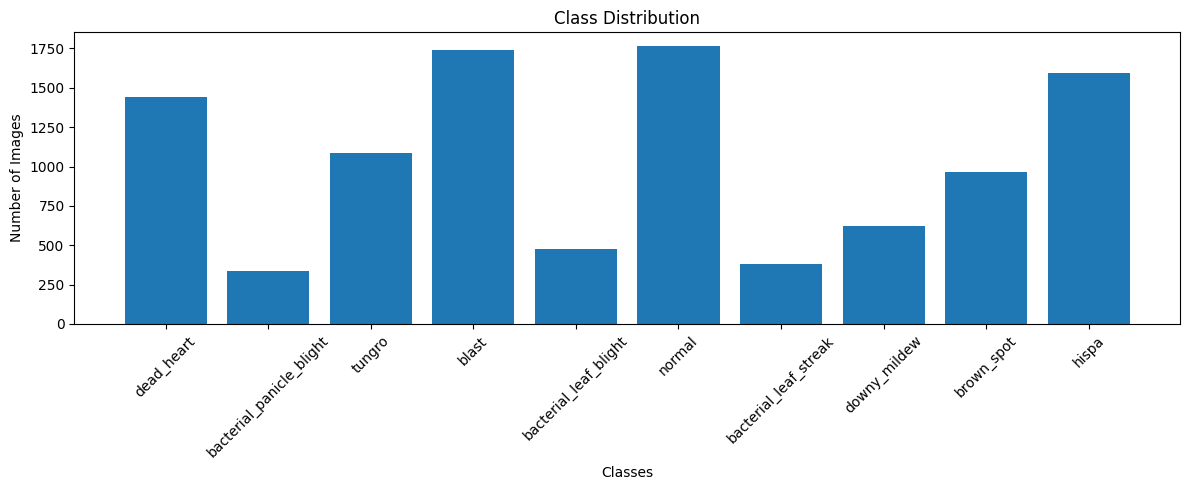

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

In [16]:
from PIL import Image
import random

# Pick 5 random classes
sample_classes = random.sample(classes, 5)

for cls in sample_classes:
    class_folder = os.path.join(train_path, cls)
    img_name = random.choice(os.listdir(class_folder))
    img_path = os.path.join(class_folder, img_name)

    try:
        img = Image.open(img_path)
        print(f"{cls} → {img.size}, Mode: {img.mode}")
    except:
        print(f"Error loading {img_path}")

downy_mildew → (480, 640), Mode: RGB
normal → (480, 640), Mode: RGB
bacterial_panicle_blight → (480, 640), Mode: RGB
tungro → (480, 640), Mode: RGB
hispa → (480, 640), Mode: RGB


In [57]:
from sklearn.model_selection import StratifiedKFold

image_paths = []
labels = []

class_to_idx = {cls: idx for idx, cls in enumerate(classes)}

for cls in classes:
    class_folder = os.path.join(train_path, cls)
    for img_name in os.listdir(class_folder):
        image_paths.append(os.path.join(class_folder, img_name))
        labels.append(class_to_idx[cls])

print("Total images collected:", len(image_paths))

Total images collected: 10407


In [18]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

folds = []

for fold, (train_idx, val_idx) in enumerate(skf.split(image_paths, labels)):
    print(f"\nFold {fold}")
    print("Train size:", len(train_idx))
    print("Validation size:", len(val_idx))
    folds.append((train_idx, val_idx))


Fold 0
Train size: 8325
Validation size: 2082

Fold 1
Train size: 8325
Validation size: 2082

Fold 2
Train size: 8326
Validation size: 2081

Fold 3
Train size: 8326
Validation size: 2081

Fold 4
Train size: 8326
Validation size: 2081


In [19]:
import numpy as np

for fold, (train_idx, val_idx) in enumerate(folds):
    val_labels = np.array(labels)[val_idx]
    unique, counts = np.unique(val_labels, return_counts=True)

    print(f"\nFold {fold} validation distribution:")
    for u, c in zip(unique, counts):
        print(f"Class {u}: {c}")


Fold 0 validation distribution:
Class 0: 289
Class 1: 67
Class 2: 218
Class 3: 347
Class 4: 96
Class 5: 353
Class 6: 76
Class 7: 124
Class 8: 193
Class 9: 319

Fold 1 validation distribution:
Class 0: 289
Class 1: 67
Class 2: 218
Class 3: 347
Class 4: 96
Class 5: 353
Class 6: 76
Class 7: 124
Class 8: 193
Class 9: 319

Fold 2 validation distribution:
Class 0: 288
Class 1: 68
Class 2: 217
Class 3: 348
Class 4: 96
Class 5: 353
Class 6: 76
Class 7: 124
Class 8: 193
Class 9: 318

Fold 3 validation distribution:
Class 0: 288
Class 1: 68
Class 2: 217
Class 3: 348
Class 4: 96
Class 5: 352
Class 6: 76
Class 7: 124
Class 8: 193
Class 9: 319

Fold 4 validation distribution:
Class 0: 288
Class 1: 67
Class 2: 218
Class 3: 348
Class 4: 95
Class 5: 353
Class 6: 76
Class 7: 124
Class 8: 193
Class 9: 319


from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [20]:
from torch.utils.data import Dataset
from PIL import Image

class PaddyDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, label

In [21]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [22]:
from torch.utils.data import DataLoader
import numpy as np

fold = 0
train_idx, val_idx = folds[fold]

train_paths = np.array(image_paths)[train_idx]
train_labels = np.array(labels)[train_idx]

val_paths = np.array(image_paths)[val_idx]
val_labels = np.array(labels)[val_idx]

train_dataset = PaddyDataset(train_paths, train_labels, transform=train_transform)
val_dataset = PaddyDataset(val_paths, val_labels, transform=val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Train batches: 261
Val batches: 66


In [23]:
all_folds_data = []

for fold, (train_idx, val_idx) in enumerate(folds):

    train_paths = np.array(image_paths)[train_idx]
    train_labels = np.array(labels)[train_idx]

    val_paths = np.array(image_paths)[val_idx]
    val_labels = np.array(labels)[val_idx]

    train_dataset = PaddyDataset(train_paths, train_labels, transform=train_transform)
    val_dataset = PaddyDataset(val_paths, val_labels, transform=val_transform)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

    all_folds_data.append({
        "fold": fold,
        "train_loader": train_loader,
        "val_loader": val_loader
    })

    print(f"Fold {fold} ready: Train {len(train_loader)} batches | Val {len(val_loader)} batches")

Fold 0 ready: Train 261 batches | Val 66 batches
Fold 1 ready: Train 261 batches | Val 66 batches
Fold 2 ready: Train 261 batches | Val 66 batches
Fold 3 ready: Train 261 batches | Val 66 batches
Fold 4 ready: Train 261 batches | Val 66 batches


In [24]:
import pickle

fold_indices_path = "/content/drive/MyDrive/paddy_project/fold_indices.pkl"

with open(fold_indices_path, "wb") as f:
    pickle.dump(folds, f)

print("Fold indices saved successfully.")

Fold indices saved successfully.


In [25]:
class_mapping_path = "/content/drive/MyDrive/paddy_project/class_to_idx.pkl"

with open(class_mapping_path, "wb") as f:
    pickle.dump(class_to_idx, f)

print("Class mapping saved.")

Class mapping saved.


In [26]:
images, labels_batch = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch label shape:", labels_batch.shape)

Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])


Summary

Total images: 10,407

Total classes: 10

Stratified 5-fold cross validation implemented

Data augmentation applied

PyTorch Dataset and DataLoader prepared

Fold indices saved for reproducibility

In [27]:
!pip install timm

In [28]:
import timm

model = timm.create_model(
    "resnet18",
    pretrained=True,
    num_classes=10
)

print(model)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (drop_block): Identity()
      (act1): ReLU(inplace=True)
      (aa): Identity()
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act2): ReLU(inplace=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, m

In [29]:
import torch

dummy = torch.randn(1, 3, 224, 224)

output = model(dummy)

print(output.shape)

torch.Size([1, 10])


In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

print(device)

cuda


In [31]:
import torch
import torch.nn as nn
import torch.optim as optim

In [39]:
import torch
import torch.nn as nn
import torch.optim as optim

In [32]:
criterion = nn.CrossEntropyLoss()

In [33]:
optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [34]:
images, labels_batch = next(iter(train_loader))

images = images.to(device)
labels_batch = labels_batch.to(device)

outputs = model(images)

print("Input shape :", images.shape)
print("Output shape:", outputs.shape)

Input shape : torch.Size([32, 3, 224, 224])
Output shape: torch.Size([32, 10])


In [35]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = timm.create_model(
    "resnet18",
    pretrained=True,
    num_classes=10
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)

print("Model ready.")

Model ready.


In [36]:
images, labels_batch = next(iter(train_loader))

images = images.to(device)
labels_batch = labels_batch.to(device)

outputs = model(images)

print(outputs.shape)

torch.Size([32, 10])


In [37]:
print(len(train_dataset))
print(len(train_loader))


8326
261


In [38]:
import time

start = time.time()

images, labels = next(iter(train_loader))

print("Time:", time.time() - start)

Time: 0.28343963623046875


In [48]:
!cp -r /content/drive/MyDrive/paddy_project/train_images /content/

In [77]:
model.train()

running_loss = 0

for batch_idx, (images, labels) in enumerate(train_loader):

    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    outputs = model(images)

    loss = criterion(outputs, labels)

    loss.backward()

    optimizer.step()

    running_loss += loss.item()

    if batch_idx % 50 == 0:
        print(f"Batch {batch_idx}/{len(train_loader)} | Loss: {loss.item():.4f}")

print("Average Loss:", running_loss / len(train_loader))

Batch 0/261 | Loss: 1.7361
Batch 50/261 | Loss: 1.7626
Batch 100/261 | Loss: 1.6277
Batch 150/261 | Loss: 1.7688
Batch 200/261 | Loss: 1.2451
Batch 250/261 | Loss: 1.3304
Average Loss: 1.505312858185092


In [78]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Accuracy: 61.17%


In [79]:
torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/paddy_project/resnet18_fold0_epoch1.pth"
)

print("Model saved.")

Model saved.


In [42]:
best_acc = 0

EPOCHS = 5

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # TRAIN
    model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    # VALIDATE
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    print(f"Loss: {avg_loss:.4f}")
    print(f"Validation Accuracy: {accuracy:.2f}%")

    # SAVE EVERY EPOCH
    torch.save(
        model.state_dict(),
        f"/content/drive/MyDrive/paddy_project/epoch_{epoch+1}.pth"
    )

    print(f"Epoch {epoch+1} saved")

    # SAVE BEST MODEL
    if accuracy > best_acc:
        best_acc = accuracy

        torch.save(
            model.state_dict(),
            "/content/drive/MyDrive/paddy_project/best_resnet18.pth"
        )

        print("Best model updated!")

print("\nTraining Complete")
print("Best Accuracy:", best_acc)


Epoch 1/5
Loss: 2.0333
Validation Accuracy: 40.12%
Epoch 1 saved
Best model updated!

Epoch 2/5
Loss: 1.5221
Validation Accuracy: 59.20%
Epoch 2 saved
Best model updated!

Epoch 3/5
Loss: 1.0713
Validation Accuracy: 69.01%
Epoch 3 saved
Best model updated!

Epoch 4/5
Loss: 0.8120
Validation Accuracy: 76.84%
Epoch 4 saved
Best model updated!

Epoch 5/5
Loss: 0.6328
Validation Accuracy: 82.65%
Epoch 5 saved
Best model updated!

Training Complete
Best Accuracy: 82.65257087938491


In [44]:
model.load_state_dict(
    torch.load("/content/drive/MyDrive/paddy_project/best_resnet18.pth")
)

<All keys matched successfully>

In [45]:
import os
print(os.path.exists("/content/drive/MyDrive/paddy_project/best_resnet18.pth"))

True


In [48]:
# Continue training from current model (Epoch 5)
best_acc = 82.65257087938491
for epoch in range(6, 9):   # Epochs 6, 7, 8

    print(f"\nEpoch {epoch}/8")

    # TRAIN
    model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    # VALIDATE
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    print(f"Loss: {avg_loss:.4f}")
    print(f"Validation Accuracy: {accuracy:.2f}%")

    # Save each epoch
    torch.save(
        model.state_dict(),
        f"/content/drive/MyDrive/paddy_project/epoch_{epoch}.pth"
    )

    print(f"Epoch {epoch} saved")

    # Update best model if improved
    if accuracy > best_acc:

        best_acc = accuracy

        torch.save(
            model.state_dict(),
            "/content/drive/MyDrive/paddy_project/best_resnet18.pth"
        )

        print("Best model updated!")

print("\nExtended Training Complete")
print("Best Accuracy:", best_acc)


Epoch 6/8
Loss: 0.4590
Validation Accuracy: 86.50%
Epoch 6 saved
Best model updated!

Epoch 7/8
Loss: 0.3679
Validation Accuracy: 89.19%
Epoch 7 saved
Best model updated!

Epoch 8/8
Loss: 0.3033
Validation Accuracy: 90.00%
Epoch 8 saved
Best model updated!

Extended Training Complete
Best Accuracy: 90.00480538202787


In [49]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

model.load_state_dict(
    torch.load("/content/drive/MyDrive/paddy_project/best_resnet18.pth")
)

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=classes
    )
)

                          precision    recall  f1-score   support

              dead_heart       0.98      0.95      0.96       288
bacterial_panicle_blight       0.91      0.90      0.90        67
                  tungro       0.80      0.89      0.84       218
                   blast       0.97      0.87      0.92       348
   bacterial_leaf_blight       0.82      0.75      0.78        95
                  normal       0.86      0.99      0.92       353
   bacterial_leaf_streak       0.92      0.96      0.94        76
            downy_mildew       0.82      0.80      0.81       124
              brown_spot       0.88      0.88      0.88       193
                   hispa       0.95      0.88      0.91       319

                accuracy                           0.90      2081
               macro avg       0.89      0.89      0.89      2081
            weighted avg       0.90      0.90      0.90      2081



<Figure size 1200x1200 with 0 Axes>

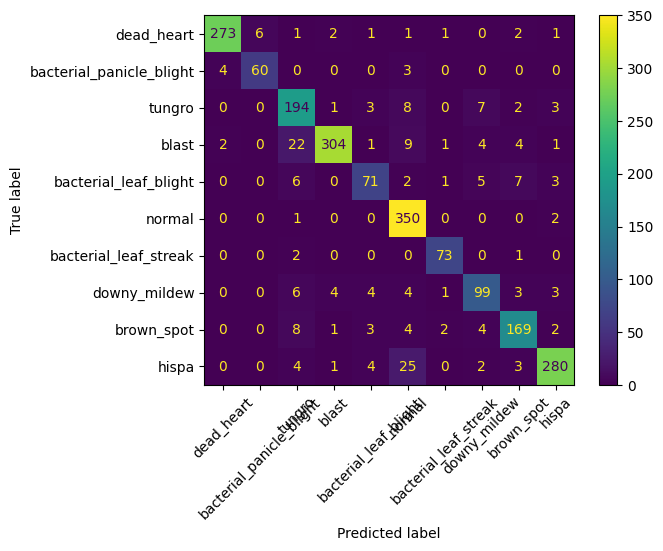

In [50]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12,12))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot(xticks_rotation=45)

plt.show()

In [51]:
plt.savefig(
    "/content/drive/MyDrive/paddy_project/confusion_matrix.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

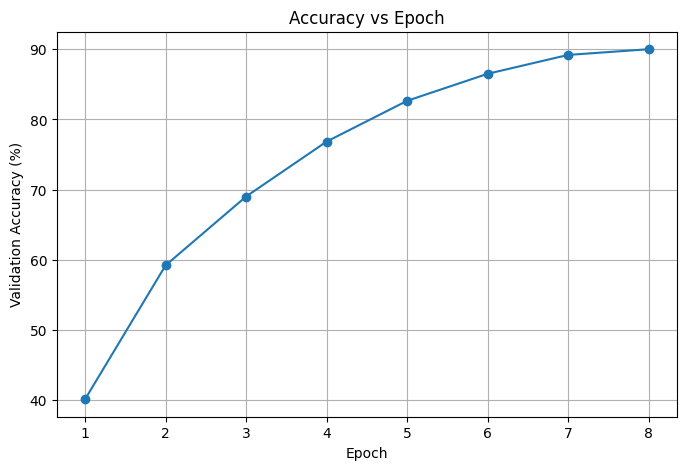

In [52]:
import matplotlib.pyplot as plt

epochs = [1,2,3,4,5,6,7,8]

accuracies = [
    40.12,
    59.20,
    69.01,
    76.84,
    82.65,
    86.50,
    89.19,
    90.00
]

plt.figure(figsize=(8,5))

plt.plot(epochs, accuracies, marker='o')

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Accuracy vs Epoch")

plt.grid(True)

plt.show()

In [53]:
plt.savefig(
    "/content/drive/MyDrive/paddy_project/accuracy_curve.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [54]:
fold_accuracies = []

In [59]:
import timm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np

fold_accuracies = [90.00]   # Fold 0 already completed

for fold, (train_idx, val_idx) in enumerate(folds):

    if fold == 0:
        continue

    print(f"\n{'='*50}")
    print(f"TRAINING FOLD {fold}")
    print(f"{'='*50}")

    train_paths = np.array(image_paths)[train_idx]
    train_labels = np.array(labels)[train_idx]

    val_paths = np.array(image_paths)[val_idx]
    val_labels = np.array(labels)[val_idx]

    train_dataset = PaddyDataset(
        train_paths,
        train_labels,
        transform=train_transform
    )

    val_dataset = PaddyDataset(
        val_paths,
        val_labels,
        transform=val_transform
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=32,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=32,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    model = timm.create_model(
        "resnet18",
        pretrained=True,
        num_classes=10
    )

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=1e-4
    )

    best_acc = 0

    for epoch in range(5):

        # TRAINING
        model.train()

        running_loss = 0

        for images, batch_labels in train_loader:

            images = images.to(device)
            batch_labels = batch_labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, batch_labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)

        # VALIDATION
        model.eval()

        correct = 0
        total = 0

        with torch.no_grad():

            for images, batch_labels in val_loader:

                images = images.to(device)
                batch_labels = batch_labels.to(device)

                outputs = model(images)

                _, predicted = torch.max(outputs, 1)

                total += batch_labels.size(0)
                correct += (predicted == batch_labels).sum().item()

        accuracy = 100 * correct / total

        print(
            f"Fold {fold} | Epoch {epoch+1}/5 | "
            f"Loss: {avg_loss:.4f} | "
            f"Accuracy: {accuracy:.2f}%"
        )

        if accuracy > best_acc:

            best_acc = accuracy

            torch.save(
                model.state_dict(),
                f"/content/drive/MyDrive/paddy_project/fold_{fold}_best.pth"
            )

    fold_accuracies.append(best_acc)

    print(f"\nFold {fold} Best Accuracy: {best_acc:.2f}%")

print("\nAll folds complete.")
print("Fold Accuracies:", fold_accuracies)

print(
    "Average Accuracy:",
    np.mean(fold_accuracies)
)


TRAINING FOLD 1
Fold 1 | Epoch 1/5 | Loss: 2.0068 | Accuracy: 44.62%
Fold 1 | Epoch 2/5 | Loss: 1.4330 | Accuracy: 60.57%
Fold 1 | Epoch 3/5 | Loss: 1.0413 | Accuracy: 71.76%
Fold 1 | Epoch 4/5 | Loss: 0.7945 | Accuracy: 76.71%
Fold 1 | Epoch 5/5 | Loss: 0.6245 | Accuracy: 83.48%

Fold 1 Best Accuracy: 83.48%

TRAINING FOLD 2
Fold 2 | Epoch 1/5 | Loss: 2.0247 | Accuracy: 45.36%
Fold 2 | Epoch 2/5 | Loss: 1.4685 | Accuracy: 60.98%
Fold 2 | Epoch 3/5 | Loss: 1.0329 | Accuracy: 71.02%
Fold 2 | Epoch 4/5 | Loss: 0.7846 | Accuracy: 78.52%
Fold 2 | Epoch 5/5 | Loss: 0.6164 | Accuracy: 80.87%

Fold 2 Best Accuracy: 80.87%

TRAINING FOLD 3
Fold 3 | Epoch 1/5 | Loss: 2.0319 | Accuracy: 42.62%
Fold 3 | Epoch 2/5 | Loss: 1.4883 | Accuracy: 64.54%
Fold 3 | Epoch 3/5 | Loss: 1.0212 | Accuracy: 73.76%
Fold 3 | Epoch 4/5 | Loss: 0.7795 | Accuracy: 79.53%
Fold 3 | Epoch 5/5 | Loss: 0.6117 | Accuracy: 84.14%

Fold 3 Best Accuracy: 84.14%

TRAINING FOLD 4
Fold 4 | Epoch 1/5 | Loss: 2.0131 | Accuracy: 4

In [58]:
print(type(labels))
print(len(labels))

<class 'list'>
10407


In [60]:
import os

print(os.path.exists("/content/drive/MyDrive/paddy_project/fold_0_best.pth"))
print(os.path.exists("/content/drive/MyDrive/paddy_project/best_resnet18.pth"))

False
True


In [61]:
model = timm.create_model(
    "resnet18",
    pretrained=False,
    num_classes=10
)

model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/paddy_project/best_resnet18.pth"
    )
)

model = model.to(device)

model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (drop_block): Identity()
      (act1): ReLU(inplace=True)
      (aa): Identity()
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act2): ReLU(inplace=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, m

In [62]:
from sklearn.metrics import classification_report
import numpy as np

all_preds = []
all_labels = []

with torch.no_grad():

    for images, batch_labels in val_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch_labels.numpy())

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=classes
    )
)

                          precision    recall  f1-score   support

              dead_heart       0.98      0.95      0.96       288
bacterial_panicle_blight       0.91      0.90      0.90        67
                  tungro       0.80      0.89      0.84       218
                   blast       0.97      0.87      0.92       348
   bacterial_leaf_blight       0.82      0.75      0.78        95
                  normal       0.86      0.99      0.92       353
   bacterial_leaf_streak       0.92      0.96      0.94        76
            downy_mildew       0.82      0.80      0.81       124
              brown_spot       0.88      0.88      0.88       193
                   hispa       0.95      0.88      0.91       319

                accuracy                           0.90      2081
               macro avg       0.89      0.89      0.89      2081
            weighted avg       0.90      0.90      0.90      2081



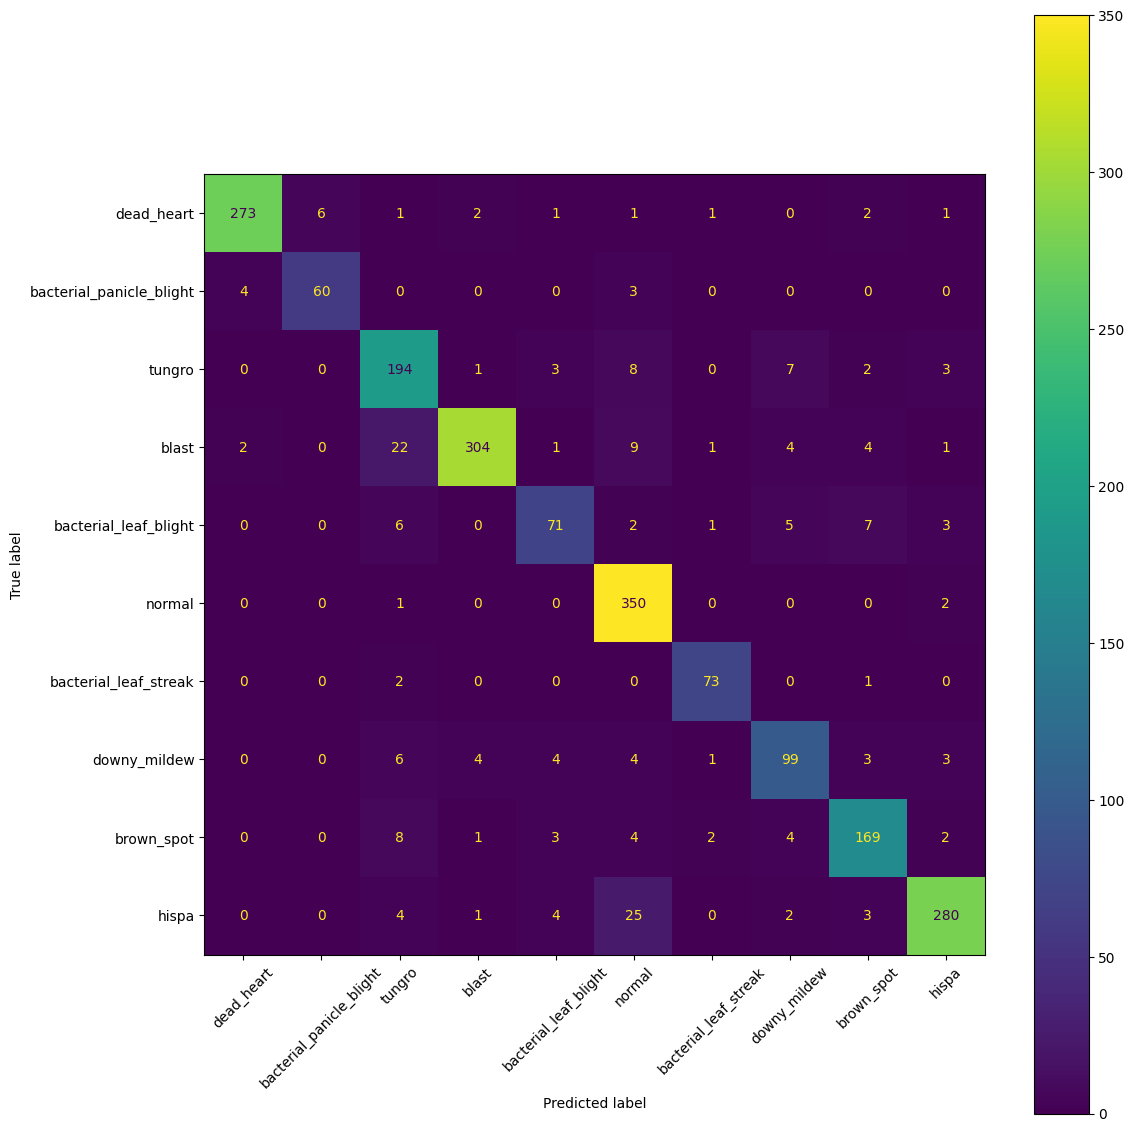

In [63]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    all_labels,
    all_preds
)

fig, ax = plt.subplots(figsize=(12,12))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/paddy_project/confusion_matrix.png"
)

plt.show()

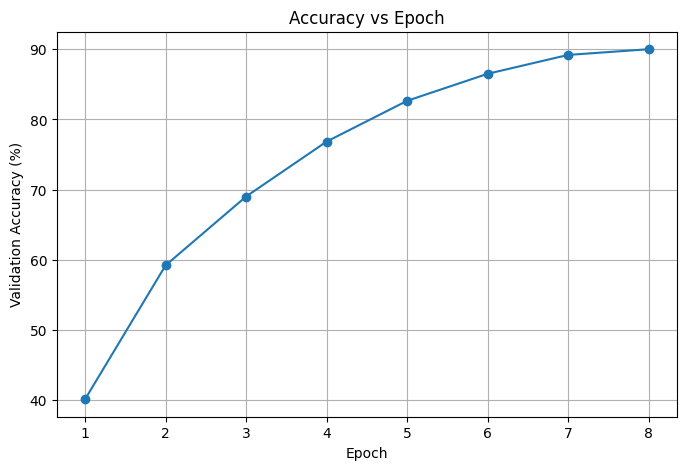

In [64]:
import matplotlib.pyplot as plt

epochs = [1,2,3,4,5,6,7,8]

accuracies = [
    40.12,
    59.20,
    69.01,
    76.84,
    82.65,
    86.50,
    89.19,
    90.00
]

plt.figure(figsize=(8,5))

plt.plot(
    epochs,
    accuracies,
    marker='o'
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Accuracy vs Epoch")

plt.grid(True)

plt.savefig(
    "/content/drive/MyDrive/paddy_project/accuracy_curve.png"
)

plt.show()

In [65]:
import pandas as pd

results = pd.DataFrame({
    "Fold": [0,1,2,3,4],
    "Accuracy": [
        90.00,
        83.4774,
        80.8746,
        84.1422,
        82.9409
    ]
})

print(results)

print(
    "\nAverage Accuracy:",
    results["Accuracy"].mean()
)

results.to_csv(
    "/content/drive/MyDrive/paddy_project/fold_results.csv",
    index=False
)

   Fold  Accuracy
0     0   90.0000
1     1   83.4774
2     2   80.8746
3     3   84.1422
4     4   82.9409

Average Accuracy: 84.28702


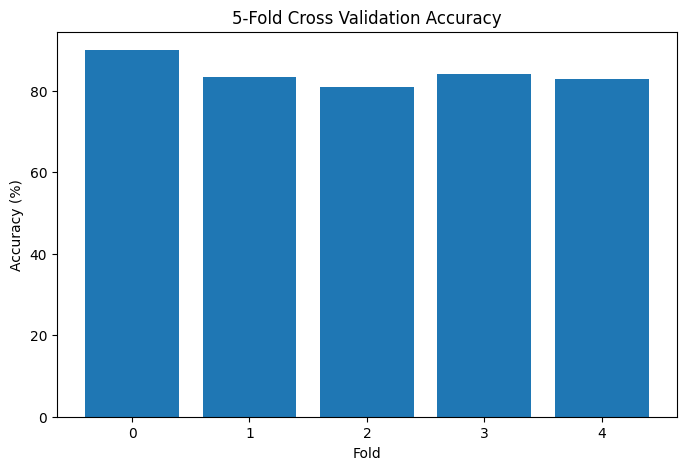

In [66]:
import matplotlib.pyplot as plt

folds_num = [0,1,2,3,4]
accuracies = [
    90.00,
    83.4774,
    80.8746,
    84.1422,
    82.9409
]

plt.figure(figsize=(8,5))

plt.bar(folds_num, accuracies)

plt.xlabel("Fold")
plt.ylabel("Accuracy (%)")
plt.title("5-Fold Cross Validation Accuracy")

plt.savefig(
    "/content/drive/MyDrive/paddy_project/fold_accuracy.png"
)

plt.show()

In [67]:
import pandas as pd

results = pd.DataFrame({
    "Fold": [0,1,2,3,4],
    "Accuracy": [
        90.00,
        83.4774,
        80.8746,
        84.1422,
        82.9409
    ]
})

results.to_csv(
    "/content/drive/MyDrive/paddy_project/fold_results.csv",
    index=False
)

print(results)
print("Average Accuracy:", results["Accuracy"].mean())

   Fold  Accuracy
0     0   90.0000
1     1   83.4774
2     2   80.8746
3     3   84.1422
4     4   82.9409
Average Accuracy: 84.28702


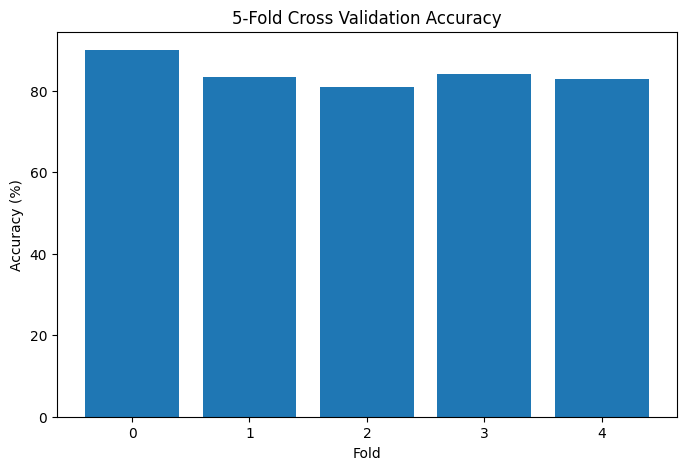

In [68]:
import matplotlib.pyplot as plt

folds_num = [0,1,2,3,4]
accuracies = [
    90.00,
    83.4774,
    80.8746,
    84.1422,
    82.9409
]

plt.figure(figsize=(8,5))

plt.bar(folds_num, accuracies)

plt.xlabel("Fold")
plt.ylabel("Accuracy (%)")
plt.title("5-Fold Cross Validation Accuracy")

plt.savefig(
    "/content/drive/MyDrive/paddy_project/fold_accuracy.png",
    bbox_inches="tight"
)

plt.show()